In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
import pandas as pd

datasets = ["electricity_benchmark", "ewz_daily"]
for d in datasets:

    df = pd.read_csv(f"./{d}_results.csv")

    display(df.head())

,Unnamed: 0,gatconv,dagg,dagg_I,baseline,gru,lstm,transformer,0.75,0.8,0.85,0.9,0.95,best_method
0,mae,42.154776,61.354731,39.509320,74.320439,42.783051,40.271284,51.603225,80.822637,108.977925,48.236773,46.547948,113.123214,dagg_I
1,rmse,336.346005,479.128658,336.309942,632.627738,347.749050,329.980390,415.956742,647.996873,866.198457,413.961820,372.421567,1038.395470,lstm
2,crps,0.044120,0.060068,0.040404,0.079289,0.043183,0.040819,0.052489,0.085803,0.116637,0.049509,0.046493,0.110515,dagg_I


,Unnamed: 0,diffconv,gatconv,dagg,dagg_I,baseline,gru,lstm,transformer,0.75,0.8,0.85,0.9,0.95,best_method
0,mae,0.101970,0.216966,0.136576,0.119713,0.161776,0.111159,0.117100,0.112211,0.113389,0.106048,0.137442,0.112352,0.145795,diffconv
1,rmse,0.629335,2.335387,0.737634,0.706468,1.308844,0.679821,0.971044,0.690096,0.738611,0.688789,0.914652,0.730686,0.927207,diffconv
2,crps,0.101425,0.185141,0.136549,0.114779,0.154440,0.107360,0.106339,0.115719,0.115946,0.106915,0.141660,0.112820,0.144823,diffconv


In [3]:
# correct for all horizons
horizon_idx = -1

(3759, 1, 261, 1) (3759, 8, 1, 261, 1)


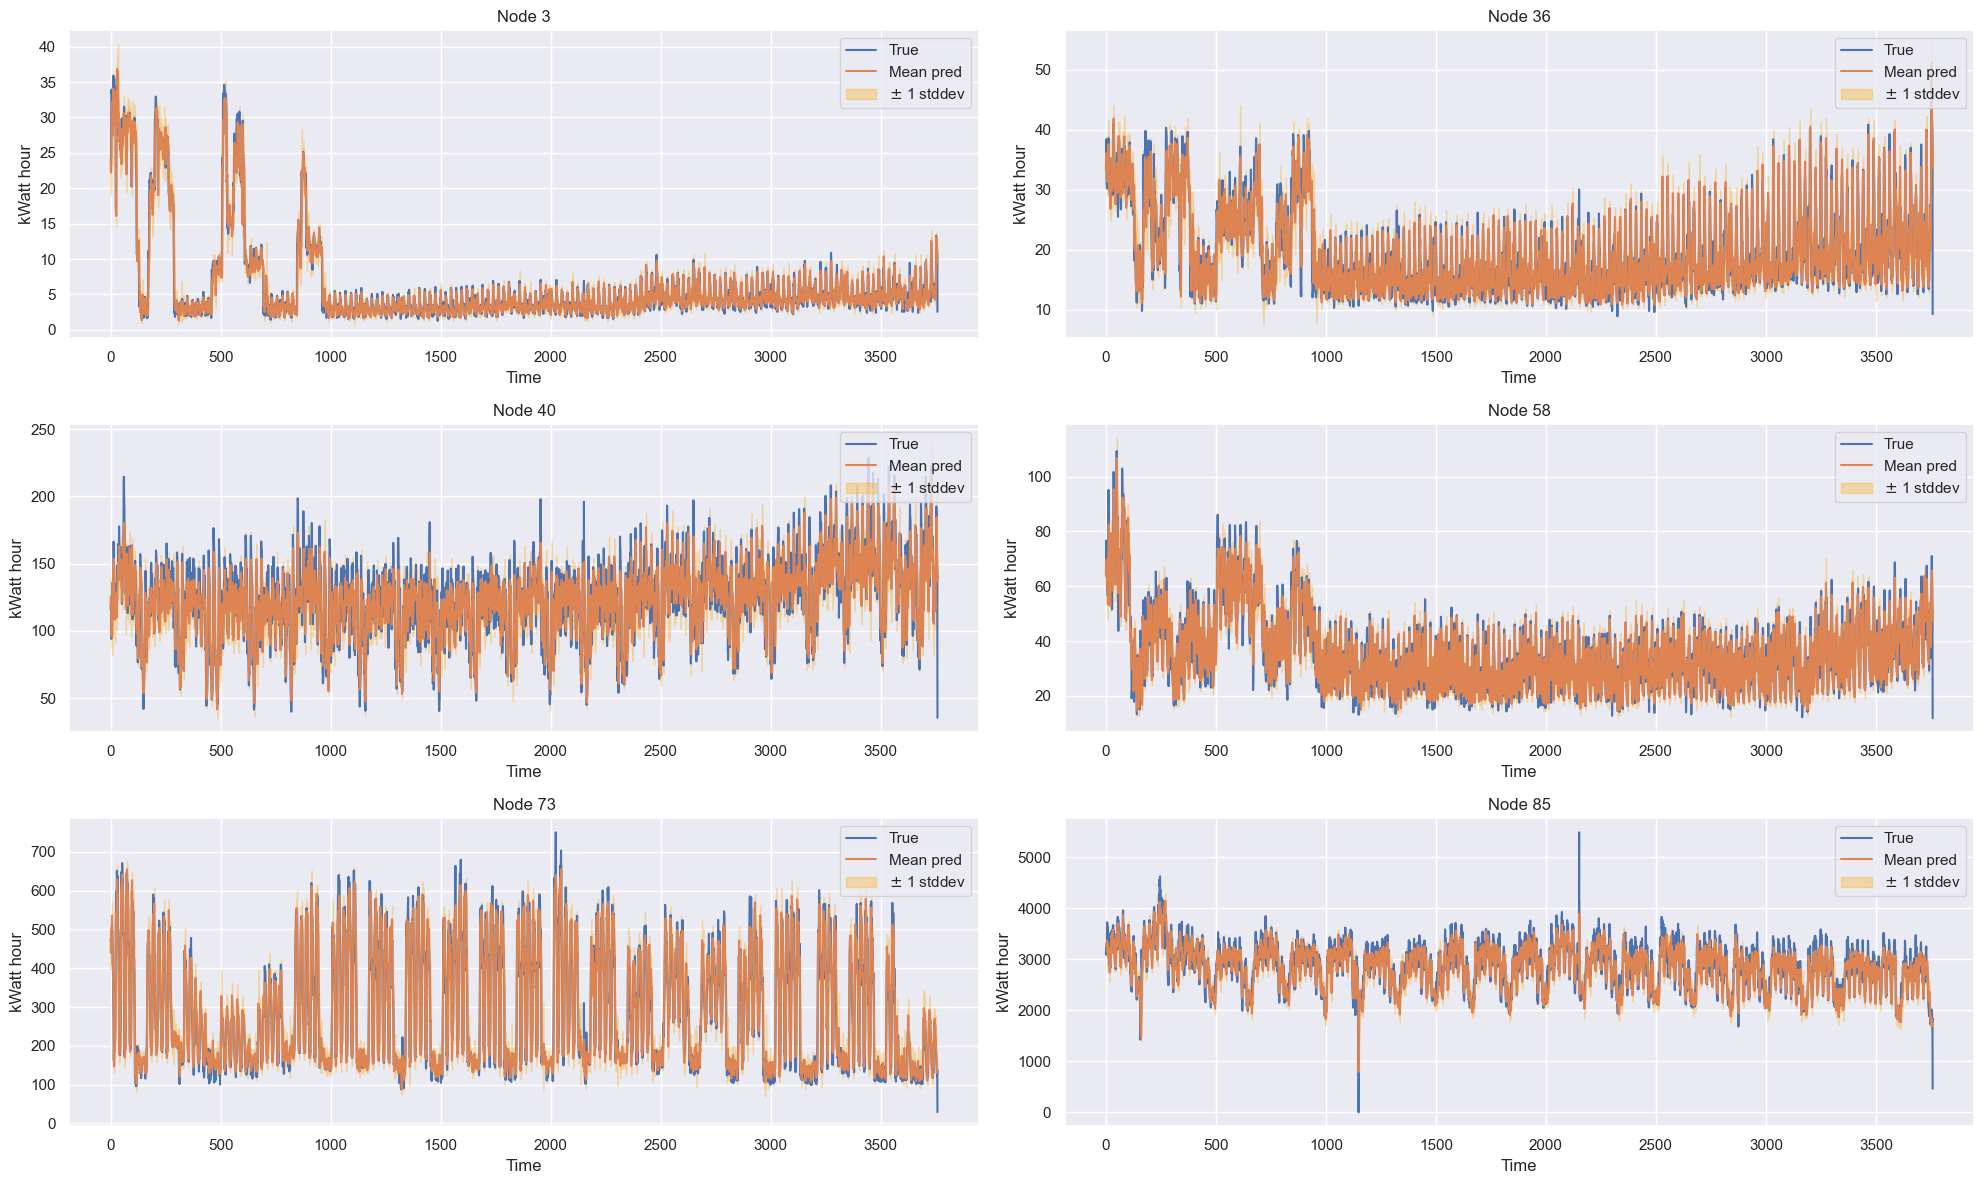

In [ ]:
y_true = np.load('./preds/true_electricity_benchmark_vanilla_dagg_I_conv_0_neighbor.npy')
y_pred = np.load('./preds/pred_electricity_benchmark_vanilla_dagg_I_conv_0_neighbor.npy')

print(y_true.shape, y_pred.shape)



y_pred_mean = y_pred.mean(axis=1)
y_pred_std  = y_pred.std(axis=1)

nodes_to_plot = [3, 36, 40, 58, 73, 85]

fig, axes = plt.subplots(3, 2, figsize=(20, 12))
axes = axes.flatten()

for i, node_idx in enumerate(nodes_to_plot):  # Only plot first 6 nodes for 2x3 grid
    node_true = y_true[:, horizon_idx, node_idx, 0]
    node_mean = y_pred_mean[:, horizon_idx, node_idx, 0]
    node_std  = y_pred_std[:, horizon_idx, node_idx, 0]

    axes[i].plot(np.arange(len(node_mean)), node_true, label='True')
    axes[i].plot(np.arange(len(node_mean)), node_mean, label='Mean pred')
    axes[i].fill_between(np.arange(len(node_mean)), 
                        node_mean - node_std, 
                        node_mean + node_std, 
                        color='orange', alpha=0.3, label=r'$\pm$ 1 stddev')
    axes[i].legend(loc='upper right')
    axes[i].set_title(f'Node {node_idx}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('kWatt hour')

plt.tight_layout()
plt.savefig("./plot/electricity_benchmark_predictions.pdf")
plt.show()


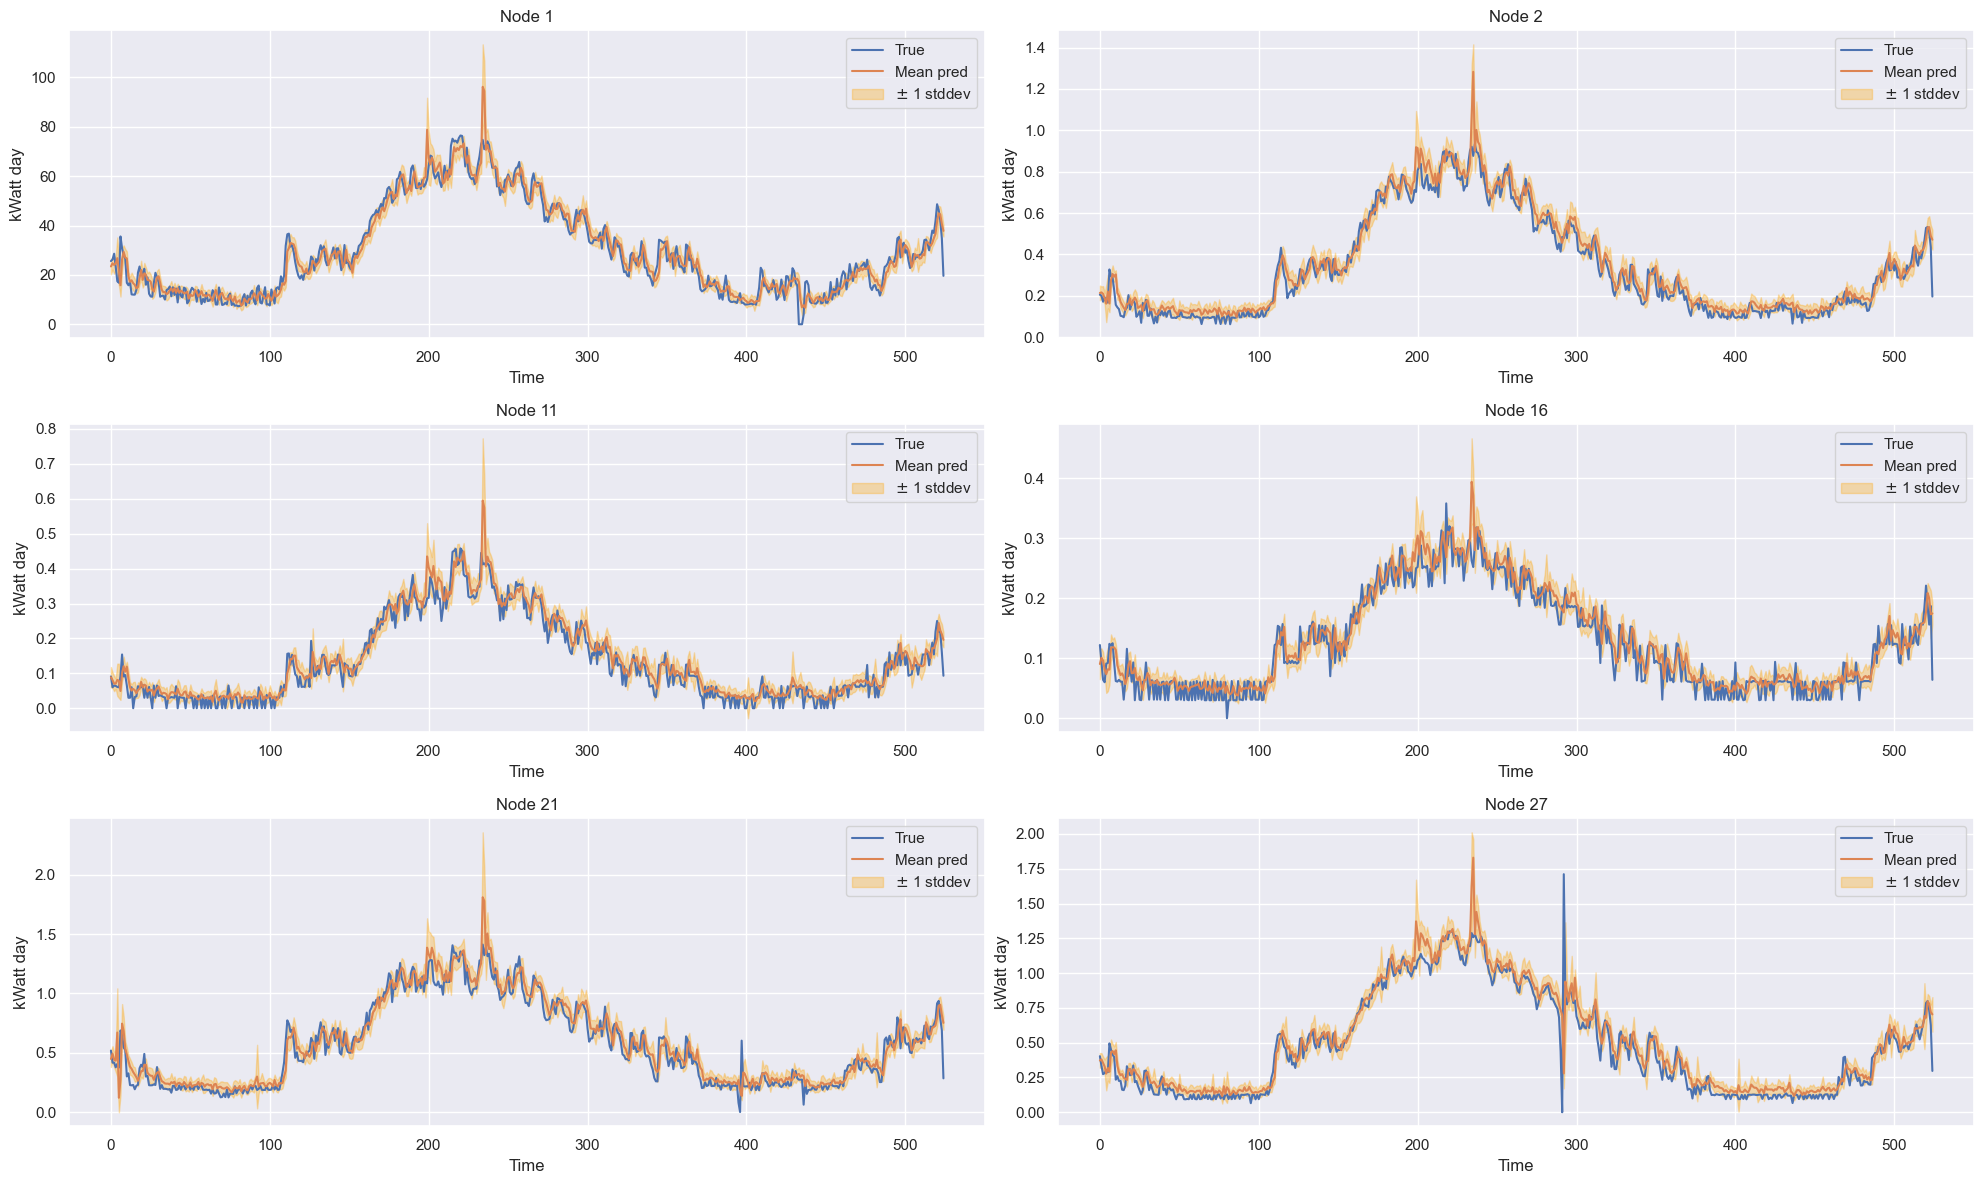

In [10]:
y_true = np.load('./preds/true_ewz_daily_diffconv_fixed_conv_0_neighbor.npy')
y_pred = np.load('./preds/pred_ewz_daily_diffconv_fixed_conv_0_neighbor.npy')

y_pred_mean = y_pred.mean(axis=1)
y_pred_std  = y_pred.std(axis=1)

nodes_to_plot = [1, 2, 11, 16, 21, 27]

fig, axes = plt.subplots(3, 2, figsize=(20, 12))
axes = axes.flatten()

for i, node_idx in enumerate(nodes_to_plot):  # Only plot first 6 nodes for 2x3 grid
    node_true = y_true[:, horizon_idx, node_idx, 0]
    node_mean = y_pred_mean[:, horizon_idx, node_idx, 0]
    node_std  = y_pred_std[:, horizon_idx, node_idx, 0]

    axes[i].plot(np.arange(len(node_mean)), node_true, label='True')
    axes[i].plot(np.arange(len(node_mean)), node_mean, label='Mean pred')
    axes[i].fill_between(np.arange(len(node_mean)), 
                        node_mean - node_std, 
                        node_mean + node_std, 
                        color='orange', alpha=0.3, label=r'$\pm$ 1 stddev')
    axes[i].legend(loc='upper right')
    axes[i].set_title(f'Node {node_idx}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('kWatt day')

plt.tight_layout()
plt.savefig("./plot/ewz_daily_predictions.pdf")
plt.show()

### Z-score anomaly detection

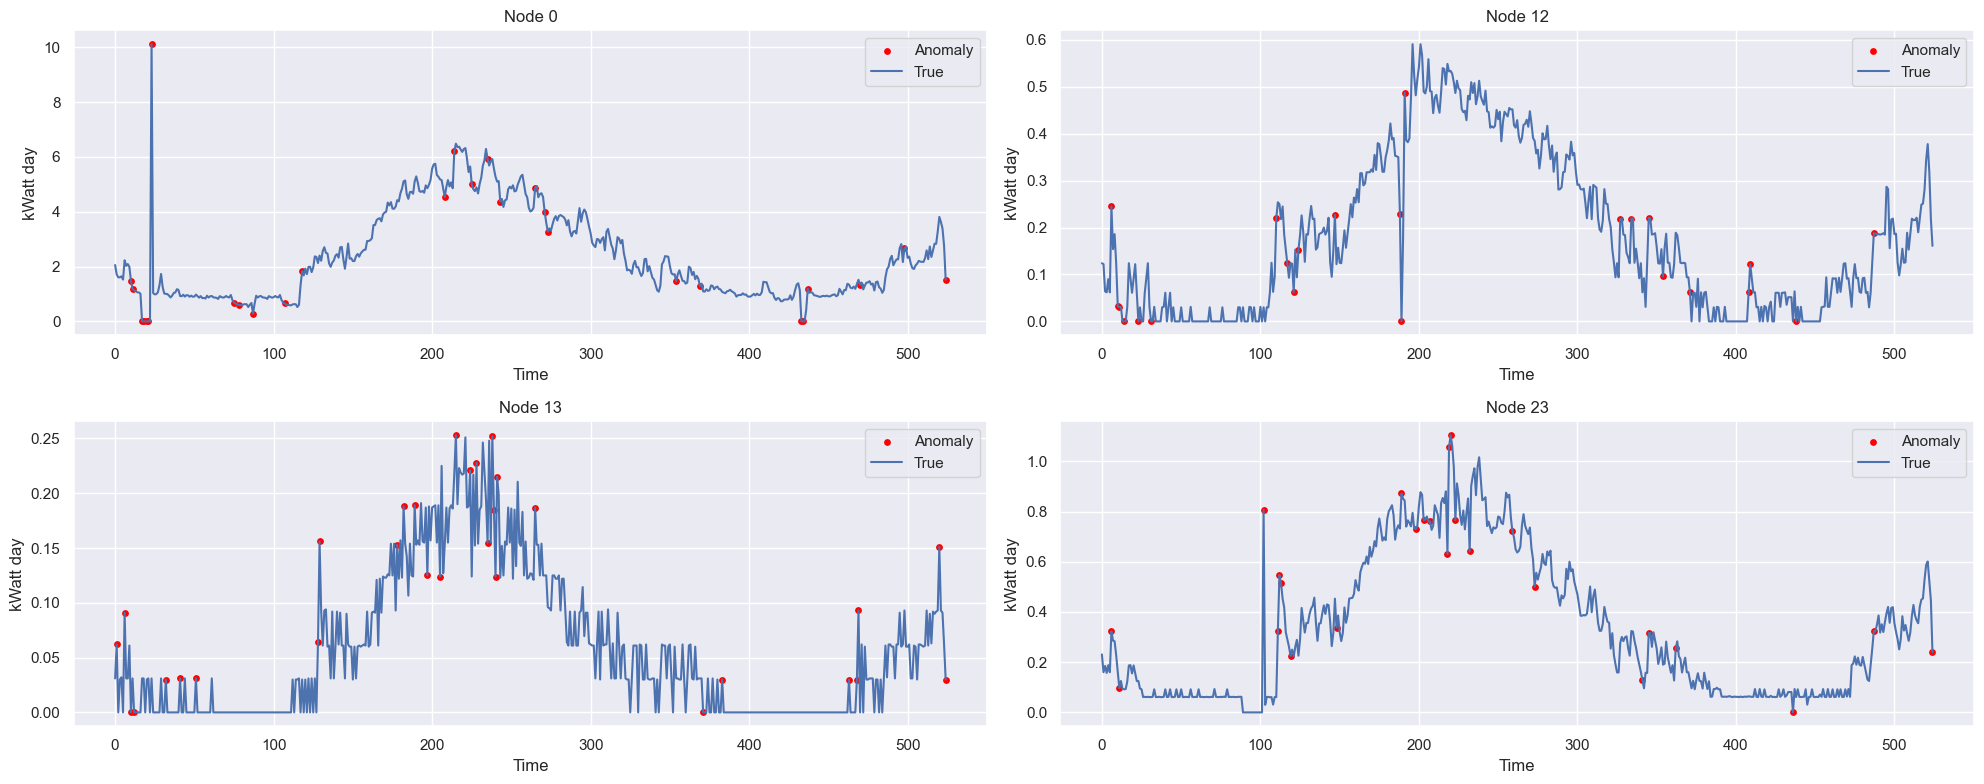

In [23]:
y_true = np.load('./preds/true_ewz_daily_diffconv_fixed_conv_0_neighbor.npy')
y_pred = np.load('./preds/pred_ewz_daily_diffconv_fixed_conv_0_neighbor.npy')

y_pred_mean = y_pred.mean(axis=1)
y_pred_std  = y_pred.std(axis=1)

nodes_to_plot = [0, 12, 13, 23]

fig, axes = plt.subplots(2, 2, figsize=(20, 8))
axes = axes.flatten()
for i, node_idx in enumerate(nodes_to_plot):
    node_true = y_true[:, horizon_idx, node_idx, 0]
    node_mean = y_pred_mean[:, horizon_idx, node_idx, 0]
    node_std  = y_pred_std[:, horizon_idx, node_idx, 0]

    err = np.abs(node_true - node_mean)
    anomaly_idx = err > 2.5 * node_std
    axes[i].scatter(np.arange(len(node_mean))[anomaly_idx], node_true[anomaly_idx], color='red', label='Anomaly', s=15)

    axes[i].plot(np.arange(len(node_mean)), node_true, label='True')
    axes[i].legend(loc='upper right')
    axes[i].set_title(f'Node {node_idx}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('kWatt day')
plt.tight_layout()
plt.savefig("./plot/ewz_daily_anomalies.pdf")
plt.show()

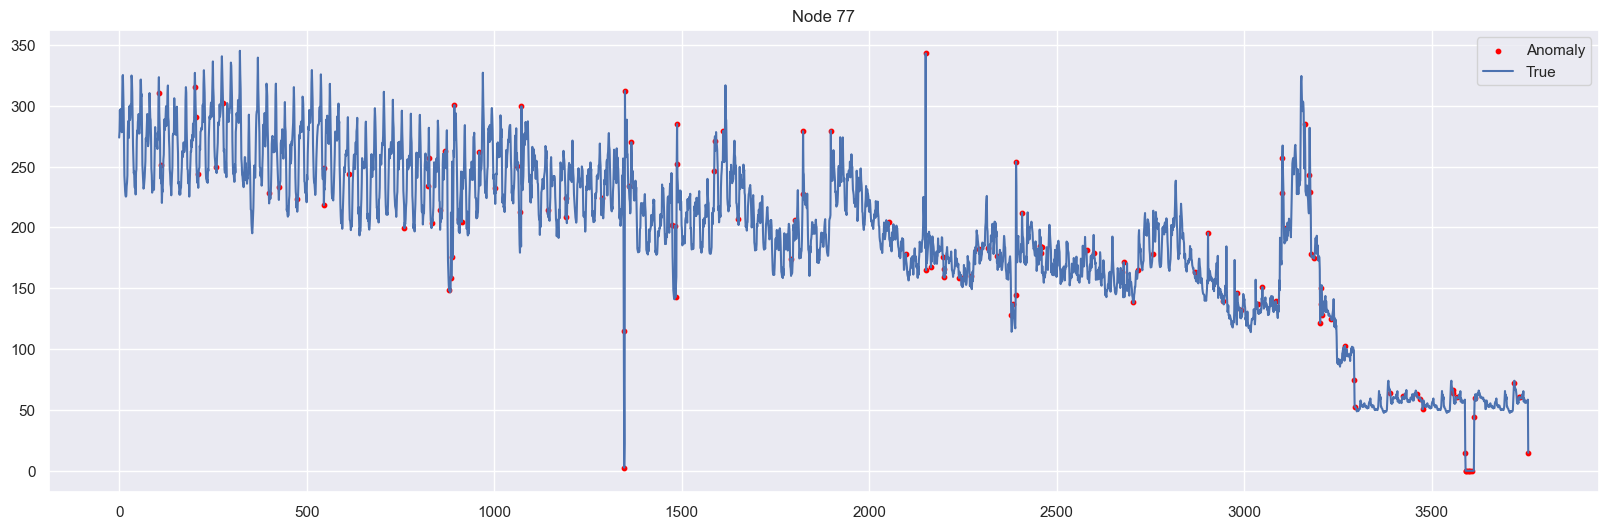

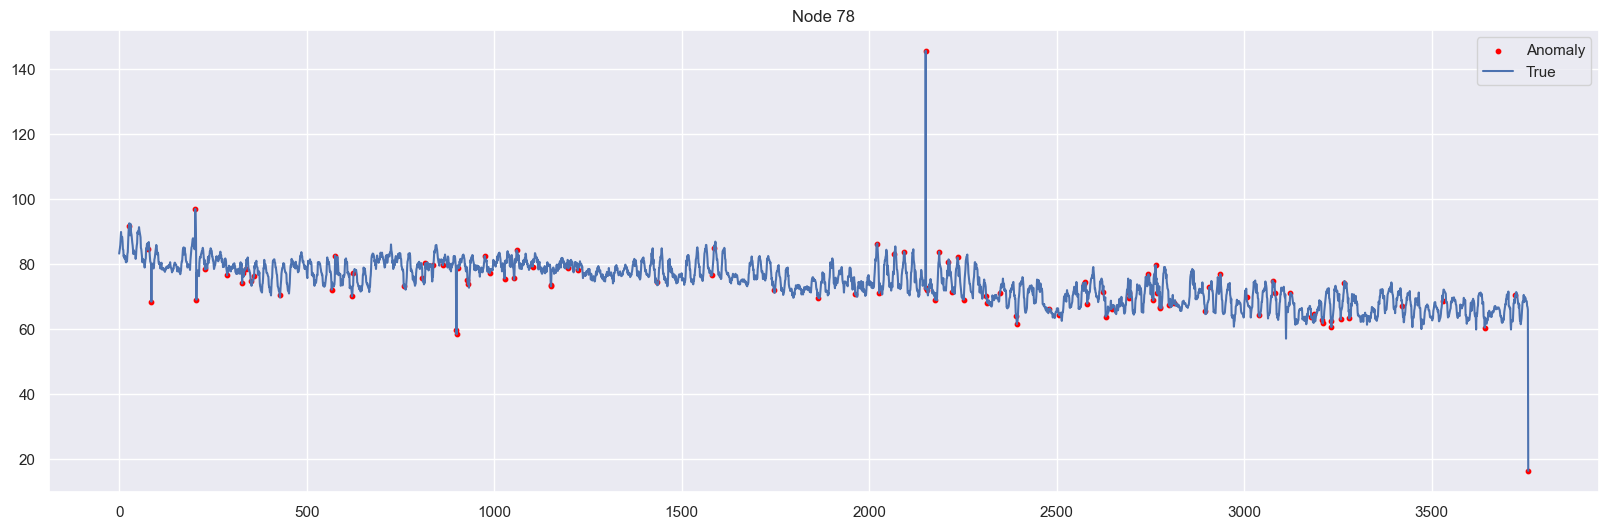

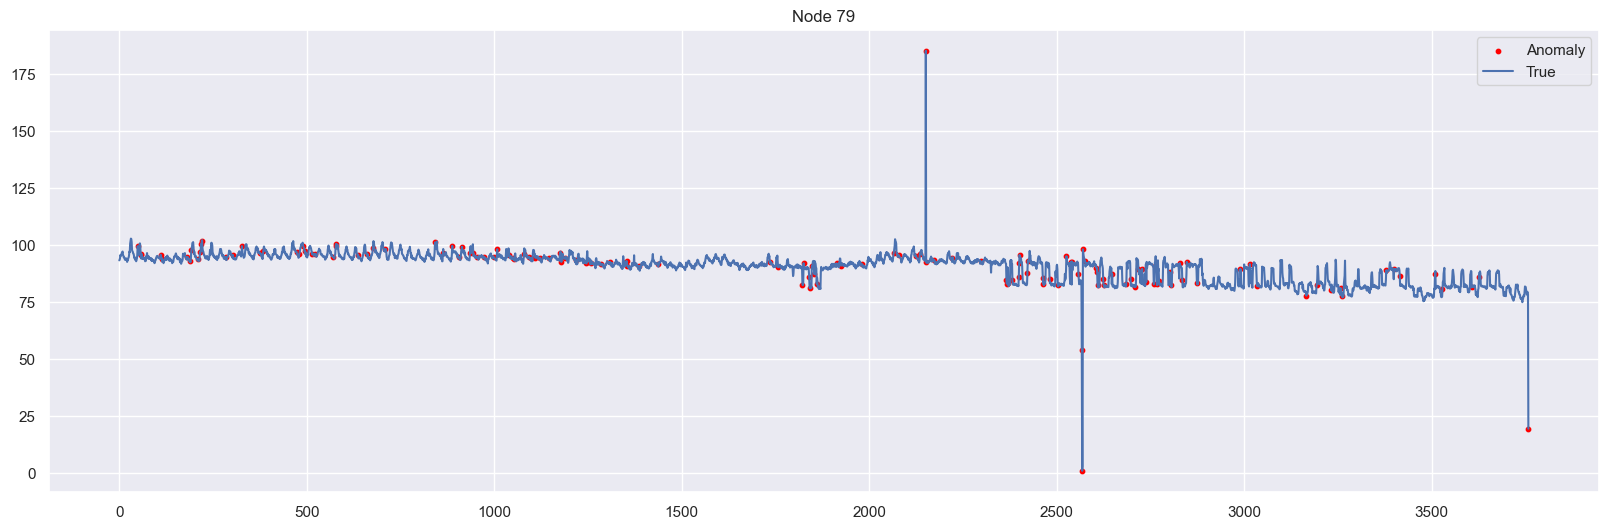

In [32]:
y_true = np.load('./preds/true_electricity_benchmark_vanilla_dagg_I_conv_0_neighbor.npy')
y_pred = np.load('./preds/pred_electricity_benchmark_vanilla_dagg_I_conv_0_neighbor.npy')

y_pred_mean = y_pred.mean(axis=1)
y_pred_std  = y_pred.std(axis=1)




for node_idx in range(77, 80):
    plt.figure(figsize=(20, 6))
    node_true = y_true[:, horizon_idx, node_idx, 0]
    node_mean = y_pred_mean[:, horizon_idx, node_idx, 0]
    node_std  = y_pred_std[:, horizon_idx, node_idx, 0]

    err = np.abs(node_true - node_mean)
    anomaly_idx = err > 3.5 * node_std
    plt.scatter(np.arange(len(node_mean))[anomaly_idx], node_true[anomaly_idx], color='red', label='Anomaly', s=10)

    plt.plot(np.arange(len(node_mean)), node_true, label='True')
    # plt.plot(np.arange(len(node_mean)), node_mean, label='Mean pred')
    # plt.fill_between(np.arange(len(node_mean)), 
    #                     node_mean - node_std, 
    #                     node_mean + node_std, 
    #                     color='orange', alpha=0.3, label=r'$\pm$ 1 stddev')
    plt.legend(loc='upper right')
    plt.title(f'Node {node_idx}')

    plt.show()

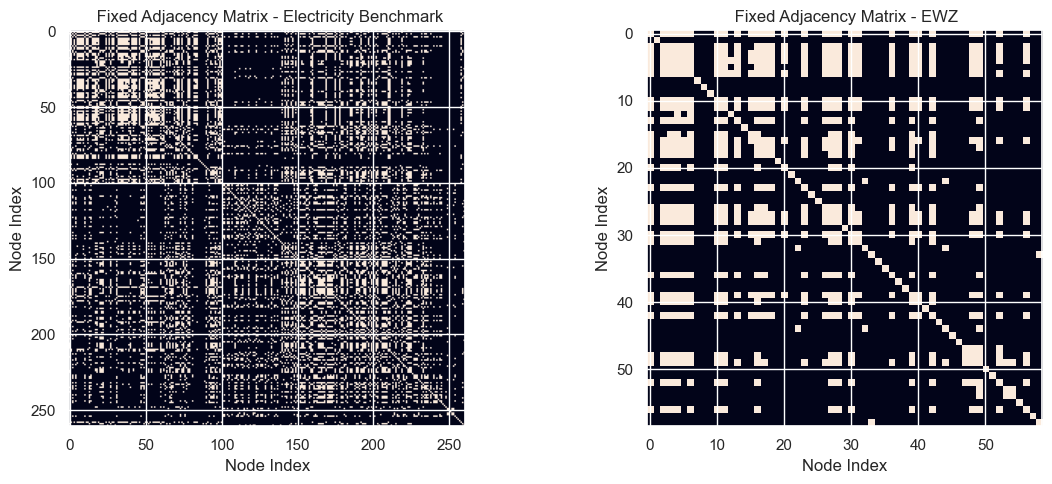

In [12]:
folders = ['electricity_benchmark', 'ewz_daily']
titles = {'electricity_benchmark': 'Electricity Benchmark', 'ewz_daily': 'EWZ'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, f in enumerate(folders):
    path = f"./data/dataset/{f}/adj.npy"
    adj = np.load(path)
    axes[idx].imshow(adj)
    axes[idx].set_title(f' Fixed Adjacency Matrix - {titles[f]}')
    axes[idx].set_xlabel('Node Index')
    axes[idx].set_ylabel('Node Index')

plt.tight_layout()
plt.savefig('./plot/fixed_adj_matrices.pdf')
plt.show()